Found behavior NWB: /root/capsule/data/behavior_nwb/776293_2025-02-19_14-01-07.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/776293_2025-02-19_14-01-07.nwb
Plotting alias 'ForagingCompareThreshold' (latent: right_choice_probability)
Found ephys NWB: /root/capsule/data/ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28/nwb/ecephys_776293_2025-02-19_14-01-07_experiment1_recording1.nwb
Successfully read ephys NWB from: /root/capsule/data/ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28/nwb/ecephys_776293_2025-02-19_14-01-07_experiment1_recording1.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/776293_2025-02-19_14-01-07.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/776293_2025-02-19_14-01-07.nwb
Successfully appended units table to behavior NWB.


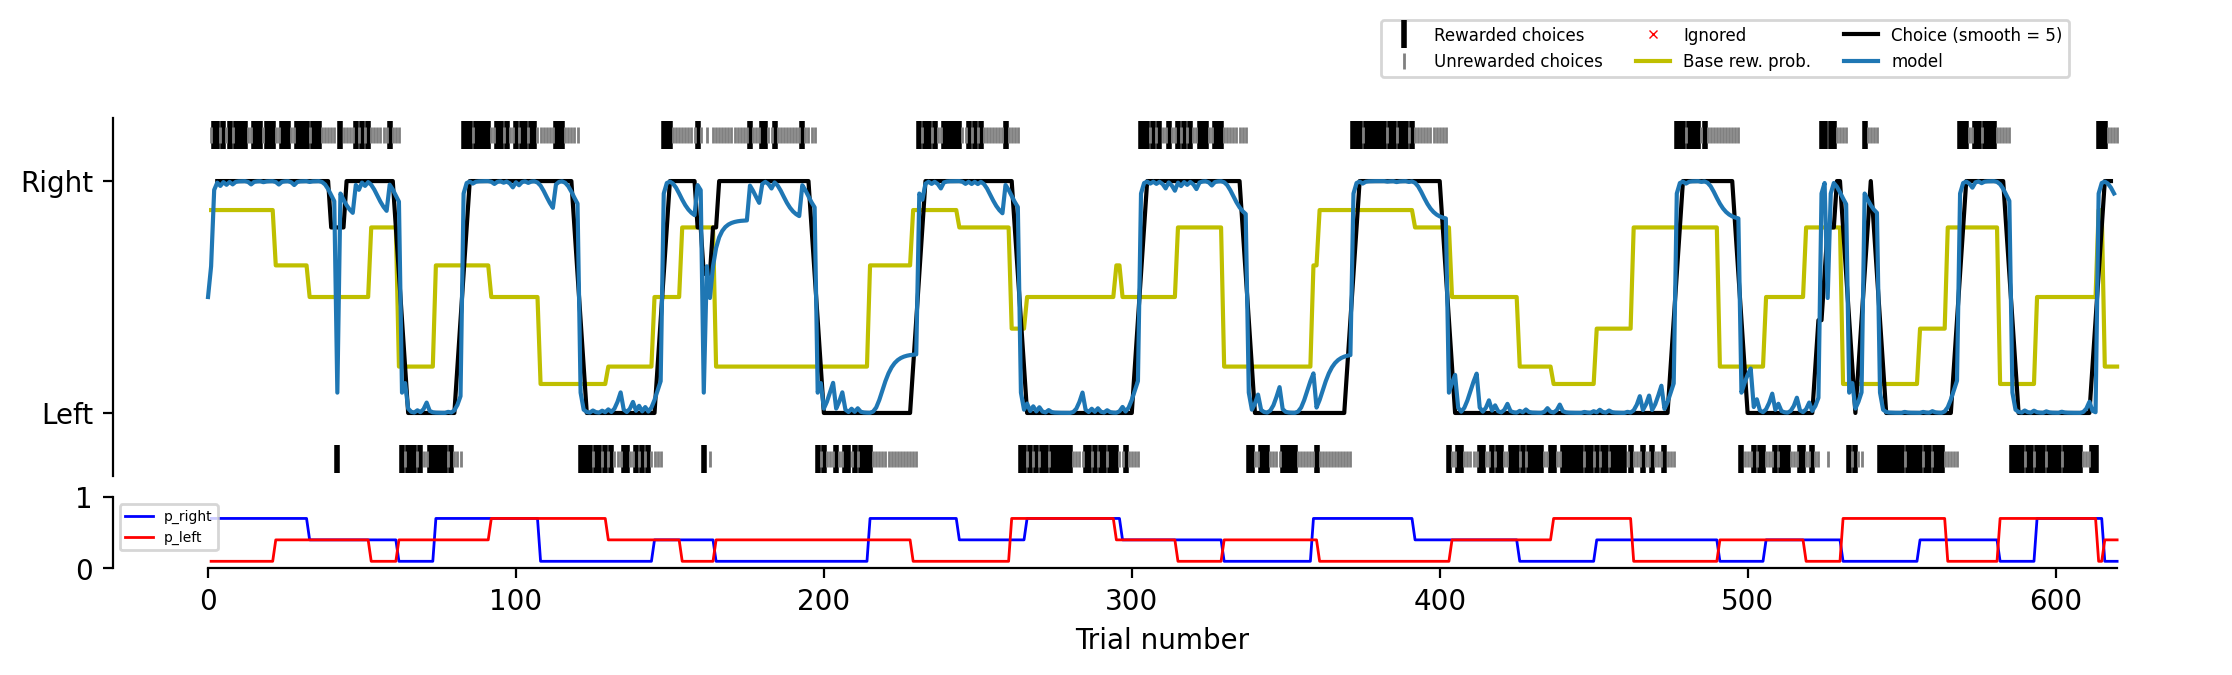

In [35]:
# load one session
import numpy as np
from create_psth import load_zarr
from general_utils import smart_read_csv, find_ephys_sessions
from general_visualization import plot_behavior_session
from nwb_utils import NWBUtils
from behavior_utils import get_fitted_model_names
from general_utils import find_behavior_sessions


sessions = find_ephys_sessions()
session = sessions[2][14]
session = 'ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28'
df = smart_read_csv(f"/root/capsule/scratch/behavior_summary-{session}.csv")
nwb_data_behavior=NWBUtils.read_behavior_nwb(session_name=session)
plot_behavior_session(nwb_data=nwb_data_behavior,model_alias='ForagingCompareThreshold',latent_name='right_choice_probability')
nwb_data,tag=NWBUtils.combine_nwb(session_name=session)

In [36]:
import numpy as np
import xarray as xr
from typing import Any, Optional, Iterable, Tuple
from pathlib import Path
import matplotlib.pyplot as plt

# If these live elsewhere in your repo, keep the imports below.
from ephys_behavior import get_units_passed_default_qc


def compute_continuous_psth_from_go_cues(
    nwb_data: Any,
    units: Optional[Iterable[int]] = None,
    bin_size: float = 0.05,
    pre_first_go: float = 3.0,
    post_last_go: float = 6.0,
    return_dataset: bool = True,
    plot_example: bool = False,
) -> xr.Dataset:
    """
    Compute a continuous PSTH (one single trace per unit) over the global window:
        [goCue_start_time[0] - pre_first_go,  goCue_start_time[-1] + post_last_go],
    with time aligned so that t=0 at goCue_start_time[0].

    Parameters
    ----------
    nwb_data : Any
        NWB handle. Must provide:
        - nwb_data.trials['goCue_start_time'] : array-like of event timestamps
        - nwb_data.units['spike_times']       : list-of-1D-arrays (per-unit spike times, seconds)
        - nwb_data.session_id (optional)      : string for metadata
    units : Iterable[int] or None
        Unit indices to include. If None, uses get_units_passed_default_qc(nwb_data).
    bin_size : float
        Bin width in seconds for the PSTH (spikes/s).
    pre_first_go : float
        Seconds to include before the first go cue (default 3.0).
    post_last_go : float
        Seconds to include after the last go cue (default 6.0).
    return_dataset : bool
        If True, return an xarray.Dataset; otherwise returns an xarray.DataArray.
    plot_example : bool
        If True, quickly plots the first unit’s PSTH for sanity check.

    Returns
    -------
    xr.Dataset
        Dataset with:
            - Data variable: 'psth_continuous' of shape (unit, time) in spikes/s
            - Coords: 'unit_index' (unit ids) and 'time' (aligned to first go cue; 0 at first go)
        Attributes include the original absolute window and bin_size.

    Notes
    -----
    - This function does NOT segment by trials. It builds a single time axis and
      bins all spikes for each unit into that axis, yielding one continuous trace per unit.
    - The output time coordinate is centered so that 0 corresponds to the first go cue.
    """

    # ---------------------------
    # 1) Collect units to use
    # ---------------------------
    if units is None:
        units = list(get_units_passed_default_qc(nwb_data))
    else:
        units = list(units)

    if len(units) == 0:
        raise ValueError("No units provided after QC selection.")

    # ---------------------------
    # 2) Define global window
    # ---------------------------
    go_cues = np.asarray(nwb_data.trials['goCue_start_time'], dtype=float)
    if go_cues.size == 0:
        raise ValueError("No goCue_start_time found in nwb_data.trials.")

    t0_abs = float(go_cues[0])                 # first go cue (absolute time)
    t1_abs = float(go_cues[-1])                # last  go cue (absolute time)
    start_abs = t0_abs - float(pre_first_go)
    end_abs   = t1_abs + float(post_last_go)

    if not np.isfinite(start_abs) or not np.isfinite(end_abs) or end_abs <= start_abs:
        raise ValueError("Invalid global window computed from go cues.")

    # Time bins (absolute), then align centers to t0_abs
    edges_abs = np.arange(start_abs, end_abs + bin_size, bin_size, dtype=float)
    centers_abs = edges_abs[:-1] + bin_size / 2.0
    time_aligned = centers_abs - t0_abs  # 0 at first go cue

    # ---------------------------
    # 3) Bin spikes for each unit
    # ---------------------------
    n_units = len(units)
    n_time = centers_abs.size
    psth = np.zeros((n_units, n_time), dtype=np.float32)

    # nwb_data.units['spike_times'] should be list-like of arrays in absolute time (seconds)
    spike_times_table = nwb_data.units["spike_times"]

    for ui, u in enumerate(units):
        spikes = np.asarray(spike_times_table[u], dtype=float)
        if spikes.size == 0:
            continue  # stays zeros
        # Restrict to [start_abs, end_abs] for speed
        mask = (spikes >= start_abs) & (spikes <= end_abs)
        spikes_in = spikes[mask]
        # Histogram → counts per bin; convert to rate
        counts, _ = np.histogram(spikes_in, bins=edges_abs)
        psth[ui, :] = counts / bin_size  # spikes/s

    # ---------------------------
    # 4) Wrap into xarray
    # ---------------------------
    da = xr.DataArray(
        psth,
        dims=("unit", "time"),
        coords={
            "unit_index": ("unit", np.asarray(units, dtype=int)),
            "time": ("time", time_aligned),
        },
        name="psth_continuous",
        attrs={
            "bin_size": float(bin_size),
            "time_alignment": "0 at goCue_start_time[0]",
            "window_absolute": (float(start_abs), float(end_abs)),
            "first_goCue_start_time": float(t0_abs),
            "last_goCue_start_time": float(t1_abs),
            "session_id": getattr(nwb_data, "session_id", "unknown"),
            "computed_with": "compute_continuous_psth_from_go_cues",
        },
    )

    if plot_example and da.shape[0] > 0:
        plt.figure(figsize=(7, 3.5))
        plt.plot(da.coords["time"].values, da.isel(unit=0).values)
        plt.axvline(0.0, color="k", linestyle="--", linewidth=0.8)
        plt.xlabel("Time aligned to first go cue (s)")
        plt.ylabel("Firing rate (spikes/s)")
        plt.title(f"Unit {int(da.coords['unit_index'].values[0])} (example)")
        plt.tight_layout()
        plt.show()

    if return_dataset:
        ds = xr.Dataset({"psth_continuous": da})
        return ds
    else:
        return da


Number of units passing QC: 1295


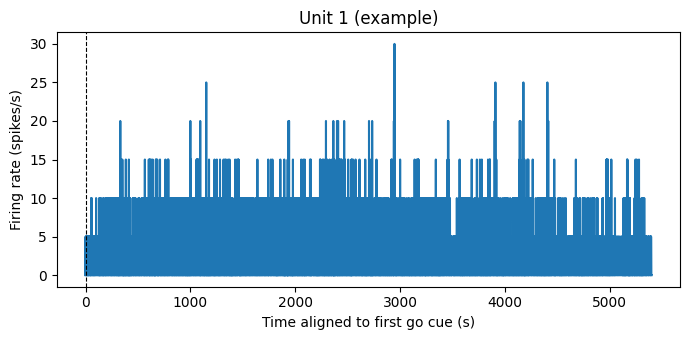

In [37]:
ds_psth = compute_continuous_psth_from_go_cues(
    nwb_data,
    units=None,          # auto-select via default QC
    bin_size=0.2,       # 50 ms
    pre_first_go=3.0,    # goCue[0]-3s
    post_last_go=6.0,    # goCue[-1]+6s
    plot_example=True
)

# Access the matrix and aligned time
psth = ds_psth["psth_continuous"]              # (unit, time)
time = ds_psth["psth_continuous"].coords["time"]


In [38]:
import numpy as np
import matplotlib.pyplot as plt

# psth: xr.DataArray with dims ("unit","time")
# time: xr.DataArray coordinate

def plot_psth_heatmap(
    psth,
    time,
    zscore_per_unit: bool = True,
    sort_by_peak_time: bool = True,
    vmin: float | None = None,
    vmax: float | None = None,
    figsize=(8, 6),
    save_path: str | None = None,
):
    # Convert to numpy
    M = np.asarray(psth.values, dtype=float)           # shape (n_units, n_time)
    t = np.asarray(time.values, dtype=float)

    # Optional z-score per unit (row): (x - mean)/std
    if zscore_per_unit:
        mu = np.nanmean(M, axis=1, keepdims=True)
        sd = np.nanstd(M, axis=1, keepdims=True)
        sd[sd == 0] = 1.0
        Mz = (M - mu) / sd
        data = Mz
        cbar_label = "Z-scored firing rate"
    else:
        data = M
        cbar_label = "Firing rate (spk/s)"

    # Optional sorting by time of max response
    if sort_by_peak_time:
        # index of max along time for each unit
        peak_idx = np.nanargmax(data, axis=1)
        order = np.argsort(peak_idx)
        data = data[order, :]
    else:
        order = np.arange(data.shape[0])

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(
        data,
        aspect="auto",
        interpolation="nearest",
        extent=[t[0], t[-1], 0, data.shape[0]],
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )
    ax.axvline(0.0, linestyle="--", linewidth=0.8, color="k")
    ax.set_xlabel("Time (s, aligned to first go cue)")
    ax.set_ylabel("Units (sorted)" if sort_by_peak_time else "Units")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    # Ticks: keep it light
    ax.set_xlim(t[0], t[-1])

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved heatmap to {save_path}")
    plt.show()




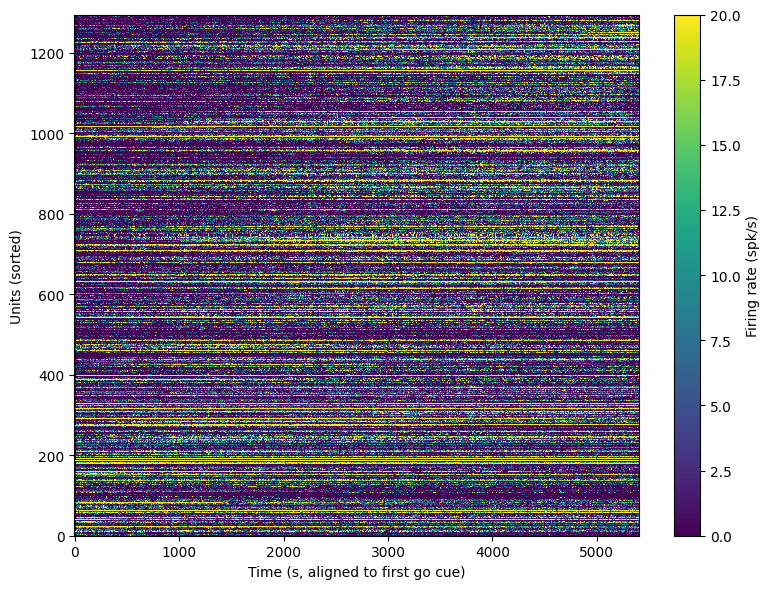

In [39]:
plot_psth_heatmap(
    psth,
    time,
    zscore_per_unit=False,      # keep raw firing rates
    sort_by_peak_time=True,
    vmin=0,                     # lower bound (spikes/s)
    vmax=20,                    # upper bound (spikes/s)
    figsize=(8, 6)
)


In [43]:
import numpy as np
import xarray as xr

def select_and_smooth_units(
    psth_like: xr.Dataset | xr.DataArray,
    var_name: str = "psth_continuous",     # used only if a Dataset is passed
    *,
    # Unit & time axis handling
    unit_dim_candidates: tuple[str, ...] = ("unit_index", "unit"),
    time_dim: str = "time",
    # Filtering & sampling
    min_mean_rate_hz: float = 1.0,         # drop units with mean rate < threshold
    n_select: int = 200,                   # number of units to sample after filtering
    seed: int = 42,
    # Smoothing
    smooth_method: str = "gaussian",       # {"gaussian", "boxcar", None}
    gaussian_sigma_s: float = 0.1,         # std (seconds) for Gaussian kernel
    gaussian_truncate: float = 3.0,        # kernel radius = truncate * sigma
    boxcar_width_s: float = 0.2,           # window length (seconds) for boxcar mean
    verbose: bool = True,
) -> tuple[xr.DataArray, np.ndarray, xr.DataArray, float]:
    """
    Returns:
        smoothed_da:  DataArray of shape (unit, time) for the sampled units
        selected_units: np.ndarray of selected unit coordinate values
        mean_rate_da:  1D DataArray of mean rates (for the filtered pool, pre-subsampling)
        bin_size_s:    inferred bin size (seconds)

    Notes:
        - Works with either a DataArray or a Dataset containing `var_name`.
        - Assumes PSTH values are already in Hz (spikes/s) or comparable rate units.
    """

    # -------------------------
    # 0) Get DataArray
    # -------------------------
    da = psth_like[var_name] if isinstance(psth_like, xr.Dataset) else psth_like
    if not isinstance(da, xr.DataArray):
        raise TypeError("Input must be an xarray DataArray or Dataset containing the variable.")

    # -------------------------
    # 1) Identify unit dimension
    # -------------------------
    unit_dim = None
    for cand in unit_dim_candidates:
        if cand in da.dims:
            unit_dim = cand
            break
        # Sometimes it is a coordinate but not the named dim; allow swap_dims
        if cand in da.coords:
            da = da.swap_dims({list(da.dims)[0]: cand}) if time_dim in da.dims else da.swap_dims({list(da.dims)[-1]: cand})
            if cand in da.dims:
                unit_dim = cand
                break
    if unit_dim is None:
        raise ValueError(f"Could not find a unit dimension among {unit_dim_candidates}. "
                         f"Found dims: {da.dims}")

    # Ensure canonical order for later numpy ops: (unit, time)
    if set(da.dims) != {unit_dim, time_dim}:
        raise ValueError(f"Expected a 2D DataArray with dims ({unit_dim}, {time_dim}). "
                         f"Got dims: {da.dims}")
    da = da.transpose(unit_dim, time_dim)

    # -------------------------
    # 2) Infer bin size (seconds)
    # -------------------------
    if "bin_size" in da.attrs:
        bin_size_s = float(da.attrs["bin_size"])
    else:
        # fall back to time coord diffs
        t = np.asarray(da.coords[time_dim].values, float)
        if len(t) < 2:
            raise ValueError("Cannot infer bin size from time axis of length < 2.")
        dt = np.diff(t)
        if not np.all(np.isfinite(dt)) or np.any(dt <= 0):
            raise ValueError("Time coordinate must be strictly increasing and finite.")
        bin_size_s = float(np.median(dt))

    # -------------------------
    # 3) Filter by mean firing rate
    # -------------------------
    mean_rate_da = da.mean(dim=time_dim)
    keep_mask = (mean_rate_da >= float(min_mean_rate_hz))
    kept_units = mean_rate_da[unit_dim].where(keep_mask, drop=True).values

    if verbose:
        print(f"[filter] mean-rate ≥ {min_mean_rate_hz} Hz: kept {kept_units.size}/{da.sizes[unit_dim]} units")

    if kept_units.size == 0:
        raise ValueError("All units were filtered out by the mean-rate threshold. "
                         "Lower the threshold or check your data scale.")

    da_filt = da.sel({unit_dim: kept_units})

    # -------------------------
    # 4) Randomly sample units (without replacement)
    # -------------------------
    rng = np.random.default_rng(seed)
    k = min(int(n_select), da_filt.sizes[unit_dim])
    selected_units = rng.choice(da_filt.coords[unit_dim].values, size=k, replace=False)
    da_sub = da_filt.sel({unit_dim: selected_units}).sortby(unit_dim)

    # -------------------------
    # 5) Smoothing along time
    # -------------------------
    def _gaussian_kernel(std_samples: float, truncate: float) -> np.ndarray:
        if std_samples <= 0:
            return np.array([1.0], dtype=float)
        radius = int(np.ceil(truncate * std_samples))
        x = np.arange(-radius, radius + 1, dtype=float)
        k = np.exp(-0.5 * (x / std_samples) ** 2)
        k /= k.sum()
        return k

    if smooth_method is None:
        smoothed_da = da_sub  # no smoothing
    elif smooth_method.lower() == "boxcar":
        win = max(1, int(round(boxcar_width_s / bin_size_s)))
        # center=True keeps alignment with original timestamps
        smoothed_da = da_sub.rolling({time_dim: win}, center=True, min_periods=1).mean()
    elif smooth_method.lower() == "gaussian":
        std_samples = float(gaussian_sigma_s / bin_size_s)
        kernel = _gaussian_kernel(std_samples, gaussian_truncate)
        # Use numpy convolution per unit
        arr = np.asarray(da_sub.values, dtype=float)  # shape: (unit, time)
        out = np.empty_like(arr)
        for i in range(arr.shape[0]):
            out[i] = np.convolve(arr[i], kernel, mode="same")
        smoothed_da = xr.DataArray(
            out,
            coords={unit_dim: da_sub.coords[unit_dim].values,
                    time_dim: da_sub.coords[time_dim].values},
            dims=(unit_dim, time_dim),
            attrs=dict(da_sub.attrs),
            name=getattr(da_sub, "name", "smoothed_psth"),
        )
        smoothed_da.attrs["smoothing"] = f"gaussian_sigma_s={gaussian_sigma_s}, truncate={gaussian_truncate}"
    else:
        raise ValueError("smooth_method must be one of {'gaussian','boxcar', None}")

    return smoothed_da, selected_units, mean_rate_da.sel({unit_dim: kept_units}), bin_size_s


In [50]:
da = ds_psth["psth_continuous"]  # (unit x time), coords: unit_index, time
smoothed_da, selected_units, mean_rate_kept, bin_size_s = select_and_smooth_units(
    da,
    min_mean_rate_hz=2,
    n_select=100,
    seed=123,
    smooth_method="gaussian",
    gaussian_sigma_s=0.2,     
    gaussian_truncate=3.0,
)

print("Selected units:", selected_units.shape, "bin_size (s):", bin_size_s)
smoothed_da  # DataArray (unit x time) ready for downstream FORCE or plotting


[filter] mean-rate ≥ 2 Hz: kept 913/1295 units
Selected units: (100,) bin_size (s): 0.2


<xarray.DataArray 'psth_continuous' (unit_index: 100, time: 27024)> Size: 22MB
array([[1.99525140e+00, 1.21018115e+00, 2.70027913e-01, ...,
        4.86288983e+00, 4.53055862e+00, 2.46469278e+00],
       [0.00000000e+00, 0.00000000e+00, 2.21652409e-02, ...,
        5.40055826e-01, 4.43304818e-02, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        4.70780685e+00, 3.49762570e+00, 1.50237430e+00],
       ...,
       [1.19287557e+01, 1.67444668e+01, 1.52228492e+01, ...,
        3.53778585e+01, 3.64535441e+01, 2.58486440e+01],
       [5.19941346e+00, 1.03156289e+01, 1.22167564e+01, ...,
        2.14343008e+01, 1.57587126e+01, 8.36755620e+00],
       [8.49762570e+00, 1.29354046e+01, 1.48891738e+01, ...,
        2.69039021e+00, 2.28744455e+00, 1.23234639e+00]],
      shape=(100, 27024))
Coordinates:
  * unit_index  (unit_index) int64 800B 14 23 24 44 61 ... 2489 2490 2538 2580
  * time        (time) float64 216kB -2.9 -2.7 -2.5 ... 5.401e+03 5.402e+03
Attributes:
    bin_size:                0.2
    time_alignment:          0 at goCue_start_time[0]
    window_absolute:         (15021422.014592, 15026826.758432)
    first_goCue_start_time:  15021425.014592
    last_goCue_start_time:   15026820.758432
    session_id:              776293_2025-02-19_14-01-07.json
    computed_with:           compute_continuous_psth_from_go_cues
    smoothing:               gaussian_sigma_s=0.2, truncate=3.0

In [64]:
# -------------------------------------------------------------
# 1. Import the unified FORCE module
# -------------------------------------------------------------
# (Assume you saved the full code as `force_pipeline.py`)
import importlib
import force_pipeline

importlib.reload(force_pipeline)

from force_pipeline import run_fullforce_pipeline_auto


# 2) (Optional) quick sanity checks
import numpy as np
t = np.asarray(smoothed_da.coords["time"].values, float)
Y = np.asarray(smoothed_da.values, float)

print("shape:", Y.shape)
print("dt ~", float(np.median(np.diff(t))))
print("any nonzero?", np.any(Y != 0))

# 3) Now call the pipeline (full-session = block_len_s<=0)
res = run_fullforce_pipeline_auto(
    psth_da=smoothed_da,
    nwb_data=nwb_data,
    block_len_s=0.0,
    tau=0.15,
    alpha=10.0,
    lam=0.995,
    clip=0.9,
    log_every=1000,
    use_tqdm=True,
    heat_vmax=20.0,
    save_path="/root/capsule/results/fullforce_single_model.npz",
    update_every=1,   # optional
)



# -------------------------------------------------------------
# 4. Inspect results
# -------------------------------------------------------------
print("Model keys:", list(res.keys()))
print("W shape:", res["W"].shape)
print("Y_hat shape:", res["Y_hat"].shape)

# Access reconstructed PSTH
Y_hat = res["Y_hat"]
U_in = res["U_in"]
t = res["t"]

# You can now visualize or compare the reconstruction:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.plot(t, Y_hat[0], label="Model")
plt.plot(t, psth_da.values[0], label="Ground Truth")
plt.xlabel("Time (s)")
plt.ylabel("Firing rate (spk/s)")
plt.title("Example Unit Reconstruction")
plt.legend()
plt.show()


shape: (100, 27024)
dt ~ 0.19999999925494194
any nonzero? True
[fullFORCE: single] U=100, T=27024, dt=0.2s
[fullFORCE] weight updates every 1 steps


fullFORCE (stable):   0%|                                             | 0/27023 [00:00<?, ?it/s]

In [ ]:
res = run_fullforce_pipeline_auto(
    psth_da=psth_da_sub,
    nwb_data=nwb_data,
    block_len_s=600.0,      # 10-min blocks if dt=0.1s (use your dt)
    tau=max(0.5*0.2, min(0.3, 2*0.2)),  # a safe tau tied to dt
    alpha=50.0,
    lam=0.99,
    clip=0.9,
    n_ctx=4,
    use_block_onehot=True,
    warm_blend=0.25,
    log_every=1000,
    use_tqdm=True,
    heat_vmax=20.0,
    save_path="/root/capsule/results/fullforce_block_model.npz",  # optional
)

shape: (100, 27024)
dt ~ 0.19999999925494194
any nonzero? True
[PCA] reduction: U=1295 -> K=100 (explained=0.615)
[fullFORCE: single] U=1295, T=27024, dt=0.2s
[fullFORCE] weight updates every 1 steps


fullFORCE (stable):   0%|                                             | 0/27023 [00:00<?, ?it/s]

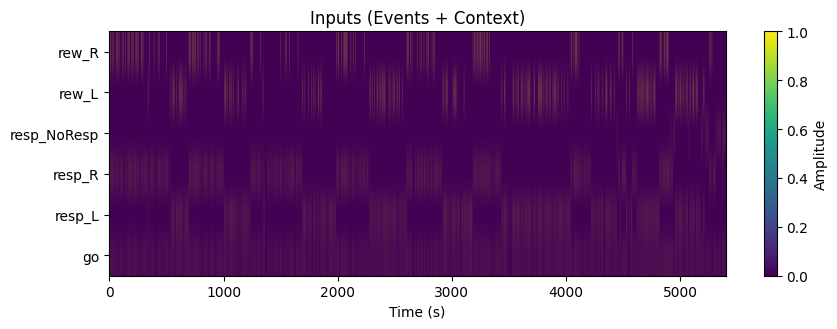

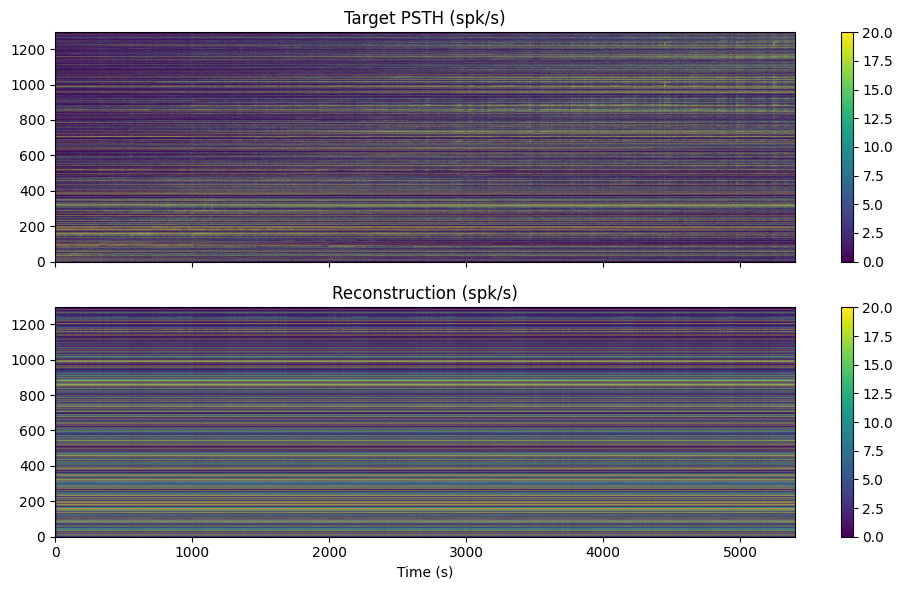

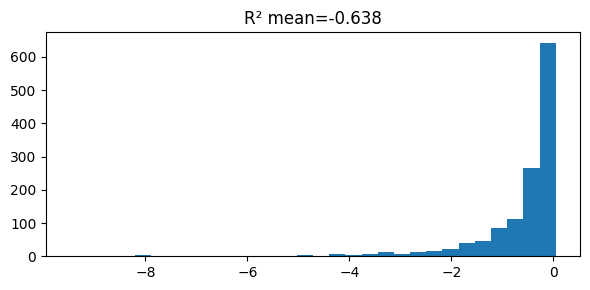

[fullFORCE: single] Saved model to: /root/capsule/results/fullforce_single_model.npz
Model keys: ['W', 'Win', 'Y_hat', 'scaler', 'U_in', 't', 'channel_names', 'pca_used', 'latent_dim', 'original_units', 'pca_model']
W shape: (100, 100)
Y_hat shape: (1295, 27024)


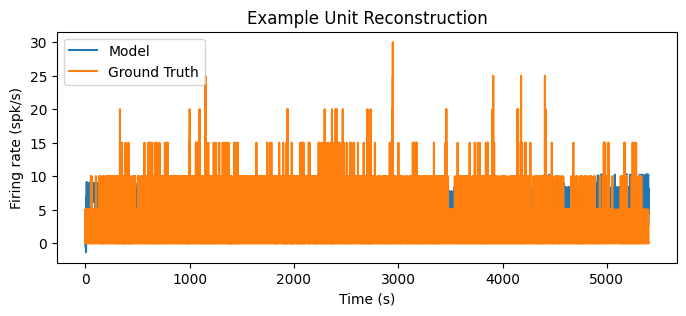

In [48]:
# -------------------------------------------------------------
# 1. Import the unified FORCE module
# -------------------------------------------------------------
# (Assume you saved the full code as `force_pipeline.py`)
import importlib
import force_pipeline

importlib.reload(force_pipeline)

from force_pipeline import run_fullforce_pipeline_auto


# -------------------------------------------------------------
# 2. Prepare your inputs
# -------------------------------------------------------------
# psth_da : your PSTH data (xarray.DataArray)
#   - dims: ("unit", "time")
#   - coordinate "time" must be in seconds
#
# nwb_data : NWB object containing behavior events, e.g.:
#   nwb_data.trials["goCue_start_time"]
#   nwb_data.trials["animal_response"]
#   nwb_data.trials["rewarded_historyL"]
#   nwb_data.trials["rewarded_historyR"]


# 1) Get the DataArray
psth_da = ds_psth["psth_continuous"]   # (unit, time)

# 3) Now call the pipeline (full-session = block_len_s<=0)
res = run_fullforce_pipeline_auto(
    psth_da=psth_da,
    nwb_data=nwb_data,
    block_len_s=0.0,      # <= 0 => no block split
    tau=0.2,
    alpha=10.0,
    lam=0.995,
    clip=0.9,
    pca_n=100,
    log_every=1000,
    use_tqdm=True,
    heat_vmax=20.0,
    save_path="/root/capsule/results/fullforce_single_model.npz",
)



# -------------------------------------------------------------
# 4. Inspect results
# -------------------------------------------------------------
print("Model keys:", list(res.keys()))
print("W shape:", res["W"].shape)
print("Y_hat shape:", res["Y_hat"].shape)

# Access reconstructed PSTH
Y_hat = res["Y_hat"]
U_in = res["U_in"]
t = res["t"]

# You can now visualize or compare the reconstruction:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.plot(t, Y_hat[0], label="Model")
plt.plot(t, psth_da.values[0], label="Ground Truth")
plt.xlabel("Time (s)")
plt.ylabel("Firing rate (spk/s)")
plt.title("Example Unit Reconstruction")
plt.legend()
plt.show()


In [49]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_pca_activity(res, psth_da, n_pcs_ts=6, scatter_downsample=5):
    """
    Compare real vs trained activity in PCA space.

    Parameters
    ----------
    res : dict
        The dict returned by run_fullforce_pipeline_auto(...).
        If training used PCA, res['pca_model'] is present.
        If block-wise, use res['Y_hat'] (stitched) and res['t'].
    psth_da : xarray.DataArray
        Original PSTH (unit x time) used for training.
    n_pcs_ts : int
        Number of leading PCs to show as time series overlays.
    scatter_downsample : int
        Downsample factor for 2D PC1–PC2 scatter to keep it light.
    """

    # 1) Pull data
    Y_true = np.asarray(psth_da.values, float)     # (U, T)
    Y_hat  = res["Y_hat"]                          # (U, T) in unit space
    t      = res["t"]

    # 2) Get or fit a PCA model
    if res.get("pca_used", False) and ("pca_model" in res) and (res["pca_model"] is not None):
        pcam = res["pca_model"]  # has .mean, .components, etc.
        mean = pcam.mean                         # (U,)
        C    = pcam.components                   # (K, U)
    else:
        # Fit a quick PCA (on the true data) just for visualization
        Y = Y_true
        mu = Y.mean(axis=1)
        Yc = Y - mu[:, None]
        Umat, S, Vt = np.linalg.svd(Yc, full_matrices=False)
        C = Umat.T                    # (U,U) -> components rows in unit space
        mean = mu
        # (We’ll just keep the leading rows of C in plotting; no need to store ratios)

    # 3) Project both true and model into the same PCA space
    def project(Y):
        return C @ (Y - mean[:, None])   # (K,U) @ (U,T) = (K,T)
    Z_true = project(Y_true)
    Z_hat  = project(Y_hat)

    # 4) Time-series overlays for the first few PCs
    K = Z_true.shape[0]
    n_show = min(n_pcs_ts, K)

    fig, axes = plt.subplots(n_show, 1, figsize=(10, 1.6*n_show), sharex=True)
    if n_show == 1:
        axes = [axes]
    for i in range(n_show):
        axes[i].plot(t, Z_true[i], lw=1.5, label="True")
        axes[i].plot(t, Z_hat[i],  lw=1.0, label="Model", alpha=0.9)
        axes[i].set_ylabel(f"PC{i+1}")
        if i == 0:
            axes[i].legend(frameon=False, ncols=2)
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"PCA time series (first {n_show} PCs) – projection shared", y=1.02)
    fig.tight_layout()
    plt.show()

    # 5) PC1–PC2 trajectory (optional scatter/line)
    if K >= 2:
        ds = max(1, int(scatter_downsample))
        plt.figure(figsize=(6.5, 5.5))
        # draw light line to show temporal order
        plt.plot(Z_true[0, ::ds], Z_true[1, ::ds], lw=1.0, alpha=0.6, label="True (line)")
        plt.plot(Z_hat[0,  ::ds], Z_hat[1,  ::ds], lw=1.0, alpha=0.6, label="Model (line)")
        # and also scatter a subset to show density
        plt.scatter(Z_true[0, ::ds], Z_true[1, ::ds], s=6, alpha=0.3, label="True (pts)")
        plt.scatter(Z_hat[0,  ::ds], Z_hat[1,  ::ds], s=6, alpha=0.3, label="Model (pts)")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.title("PC1–PC2 projection (shared PCA basis)")
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()

    # 6) Per-PC correlation / R² in PCA space (quick diagnostic)
    #    (helps see if mismatch is due to few PCs or dynamics)
    def rowwise_r2(A, B):
        num = np.sum((A - B)**2, axis=1)
        den = np.sum((A - A.mean(axis=1, keepdims=True))**2, axis=1)
        with np.errstate(divide="ignore", invalid="ignore"):
            r2 = 1.0 - num / den
        r2[~np.isfinite(r2)] = np.nan
        return r2

    r2_pc = rowwise_r2(Z_true[:n_show], Z_hat[:n_show])
    plt.figure(figsize=(6,3))
    plt.bar(np.arange(1, n_show+1), r2_pc)
    plt.xlabel("PC #")
    plt.ylabel("R²")
    plt.title(f"R² per PC (first {n_show} PCs) — mean={np.nanmean(r2_pc):.3f}")
    plt.tight_layout()
    plt.show()


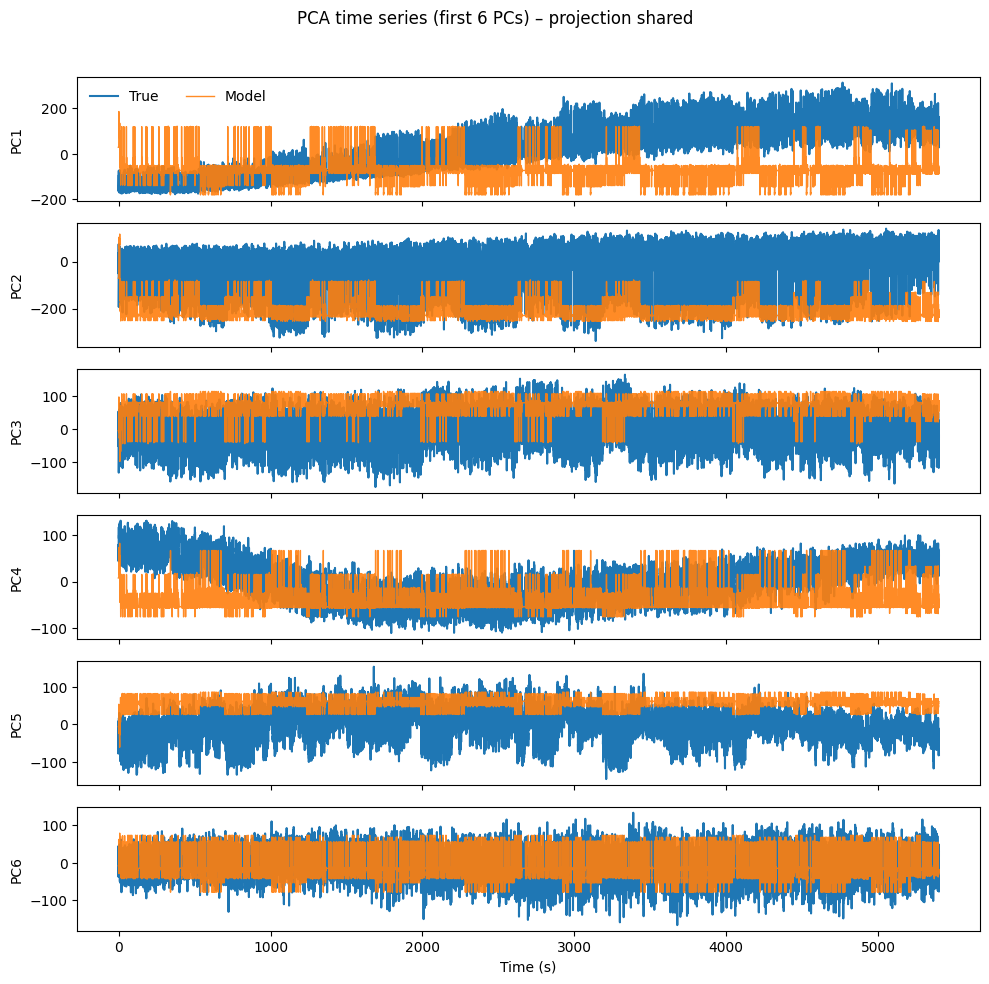

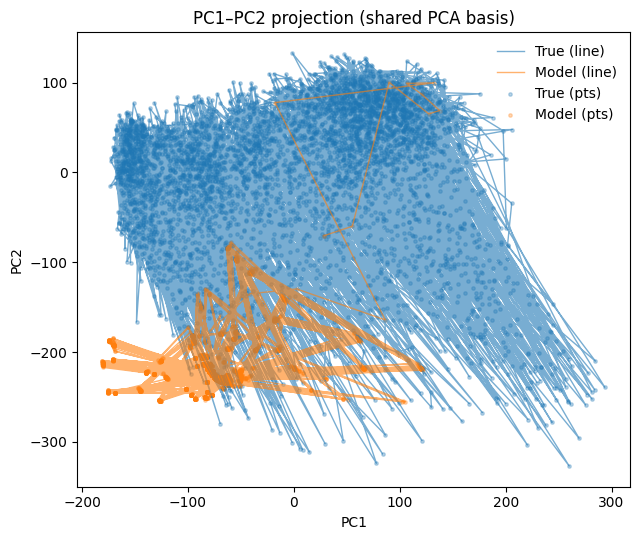

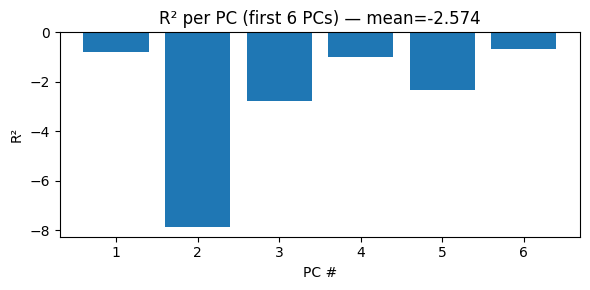

In [50]:
visualize_pca_activity(res, psth_da, n_pcs_ts=6, scatter_downsample=5)